# 03 — Distillation smoke test

**Goal.** Verify the FinBERT-distillation pipeline trains end-to-end and that
the student actually *inherits the teacher's semantic geometry* — and quantify
the one thing distillation exists to buy: **speed**.

**Why distil.** FinBERT (teacher, `ProsusAI/finbert`, ~110M params) is too heavy
for our latency budget — we need a semantic embedding within a few ms per
headline, sometimes on CPU. The student
(`DistilledFinancialEncoder`, ~11M params, 4 transformer layers) trades capacity
for speed while keeping the teacher's representation *direction* and *magnitude*,
which the distillation loss enforces.

**What this notebook now measures** (beyond "loss went down"):

1. **Speed** — teacher vs student latency / throughput / params / on-disk size,
   CPU and GPU. This is the headline justification for distillation.
2. **Geometry preservation** — teacher↔student cosine alignment, linear **CKA**,
   and **kNN-retrieval overlap** between the two embedding spaces.
3. **Downstream utility** — a linear sentiment probe on frozen teacher vs student
   embeddings; the accuracy gap is the semantics actually retained.
4. **Token attribution** — Integrated Gradients on the student to show *which
   words* drive its embedding.

This is still a smoke test (36 labelled headlines, 30 epochs); a real run sees
millions of headlines for hours (`backend/perception/semantic/distillation.py`).

In [1]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer

from backend.perception.semantic.distilled_llm import (
    TEACHER_MODEL,
    DistilledFinancialEncoder,
    load_teacher,
)

torch.manual_seed(42)
np.random.seed(42)
plt.style.use("dark_background")
COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "accent": "#ab47bc",
}
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

/home/pyros05/Escritorio/lumina_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 1. A small *labelled* headline corpus

Three sentiment classes (bearish / neutral / bullish), 12 each. Labels let us
run a downstream probe; the variety stops the student from trivially memorising
six sentences (the old version repeated 6 headlines ×10).

In [2]:
BEARISH = [
    "Shares plunge after the company slashes full-year guidance.",
    "Regulators open a fraud probe into the bank's accounting.",
    "Crude oil collapses 8% on demand-destruction fears.",
    "The chipmaker warns of a catastrophic supply-chain failure.",
    "Quarterly losses widen as margins crater across every segment.",
    "Credit downgrade pushes borrowing costs to multi-year highs.",
    "Layoffs deepen as the retailer files for bankruptcy protection.",
    "The drugmaker's lead trial fails its primary endpoint.",
    "Profit warning wipes a third off the airline's market value.",
    "Default risk spikes as the developer misses a bond payment.",
    "Demand evaporates and inventories balloon to record levels.",
    "The stock craters after a surprise dividend suspension.",
]
NEUTRAL = [
    "The company will report earnings after the close on Thursday.",
    "Trading volumes were broadly in line with the prior session.",
    "The central bank left interest rates unchanged, as expected.",
    "Management reiterated its previously issued annual outlook.",
    "The firm scheduled its annual shareholder meeting for May.",
    "Index constituents were rebalanced in the quarterly review.",
    "The merger awaits routine regulatory approval later this year.",
    "Analysts left their price targets unchanged after the call.",
    "The bond matures in 2031 and pays a fixed semi-annual coupon.",
    "The exchange published its monthly market-activity statistics.",
    "The CFO presented at an industry conference on Tuesday.",
    "The company filed its standard quarterly report with the SEC.",
]
BULLISH = [
    "Earnings smash expectations and guidance is raised sharply.",
    "The stock soars to a record high on blockbuster iPhone demand.",
    "A landmark drug approval opens a multi-billion-dollar market.",
    "Margins expand as cost cuts flow straight to the bottom line.",
    "The chipmaker lands a massive AI-accelerator supply contract.",
    "Free cash flow surges and the board triples the buyback.",
    "Subscriber growth blows past the most bullish estimates.",
    "Upgraded to buy as the turnaround gains undeniable traction.",
    "Record bookings signal accelerating, durable revenue growth.",
    "The bank crushes stress tests and hikes its dividend.",
    "Breakthrough orders push the backlog to an all-time high.",
    "Shares rally as the company reinstates and raises guidance.",
]
HEADLINES = BEARISH + NEUTRAL + BULLISH
LABELS = np.array([0] * 12 + [1] * 12 + [2] * 12)
LABEL_NAMES = ["bearish", "neutral", "bullish"]
print(f"{len(HEADLINES)} headlines, {len(set(LABELS))} classes (balanced)")

36 headlines, 3 classes (balanced)


## 2. Load teacher + student; size comparison

In [3]:
tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL)
teacher = load_teacher(device=device)
student = DistilledFinancialEncoder().to(device)


def n_params(m):
    return sum(p.numel() for p in m.parameters())


def size_mb(m):
    return sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6


t_p, s_p = n_params(teacher), n_params(student)
print(f"{'model':<10}{'params':>14}{'size (MB)':>12}")
print(f"{'teacher':<10}{t_p:>14,}{size_mb(teacher):>12.1f}")
print(f"{'student':<10}{s_p:>14,}{size_mb(student):>12.1f}")
print(
    f"\nCompression: {t_p / s_p:.1f}× fewer params, {size_mb(teacher) / size_mb(student):.1f}× smaller"
)
assert 8e6 < s_p < 25e6, "Student size out of expected range"


def encode(texts, max_len=64):
    return tokenizer(
        list(texts), padding="max_length", truncation=True, max_length=max_len, return_tensors="pt"
    ).to(device)

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 60134.47it/s]
[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model             params   size (MB)
teacher      109,482,240       437.9
student       11,318,080        45.3

Compression: 9.7× fewer params, 9.7× smaller


## 3. Distillation loop (30 epochs, batched, loss decomposed)

The loss is a 50/50 mix: **MSE** pins the magnitude of the teacher's CLS vector,
**cosine** pins its direction. We track each term separately so we can see them
fall together — the student is matching *both* shape and scale.

In [4]:
enc_all = encode(HEADLINES)
with torch.no_grad():
    teacher_cls = teacher(**enc_all).last_hidden_state[:, 0]  # (N, 768)

opt = torch.optim.AdamW(student.parameters(), lr=5e-5)
ids, mask = enc_all["input_ids"], enc_all["attention_mask"]
N, BS = len(HEADLINES), 16
hist = {"total": [], "mse": [], "cos": []}

for epoch in range(30):
    student.train()
    perm = torch.randperm(N, device=device)
    agg = {"total": 0.0, "mse": 0.0, "cos": 0.0}
    for i in range(0, N, BS):
        b = perm[i : i + BS]
        _, s_proj = student(ids[b], mask[b])
        l_mse = F.mse_loss(s_proj, teacher_cls[b])
        l_cos = 1.0 - F.cosine_similarity(s_proj, teacher_cls[b]).mean()
        loss = 0.5 * l_mse + 0.5 * l_cos
        opt.zero_grad()
        loss.backward()
        opt.step()
        agg["total"] += loss.item()
        agg["mse"] += l_mse.item()
        agg["cos"] += l_cos.item()
    for k in hist:
        hist[k].append(agg[k] / np.ceil(N / BS))
    if epoch % 5 == 0:
        print(
            f"epoch {epoch:2d}  total={hist['total'][-1]:.4f}  mse={hist['mse'][-1]:.4f}  cos={hist['cos'][-1]:.4f}"
        )

assert hist["total"][-1] < hist["total"][0], "Distillation did not reduce the loss"
print("PASS — distillation pipeline reduces the alignment loss.")

epoch  0  total=0.7178  mse=0.4562  cos=0.9794
epoch  5  total=0.5599  mse=0.3790  cos=0.7408
epoch 10  total=0.4780  mse=0.3321  cos=0.6239
epoch 15  total=0.4275  mse=0.3034  cos=0.5515
epoch 20  total=0.3777  mse=0.2762  cos=0.4791
epoch 25  total=0.3266  mse=0.2466  cos=0.4066
PASS — distillation pipeline reduces the alignment loss.


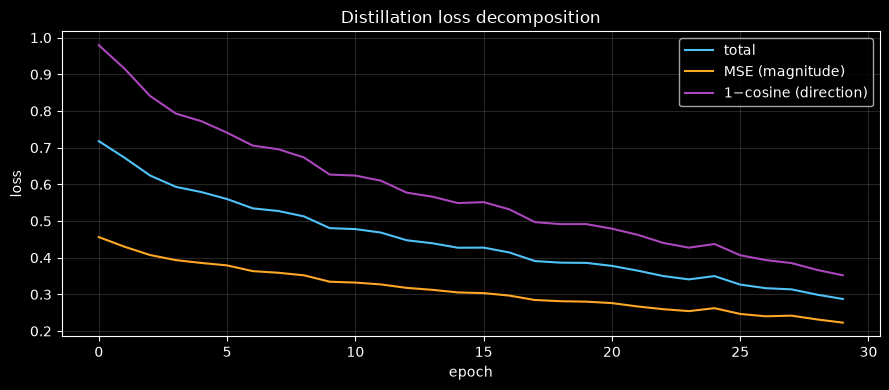

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist["total"], color=COLORS["primary"], label="total")
ax.plot(hist["mse"], color=COLORS["warning"], label="MSE (magnitude)")
ax.plot(hist["cos"], color=COLORS["accent"], label="1−cosine (direction)")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Distillation loss decomposition")
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 4. Geometry preservation

Three complementary views of "did the student keep the teacher's geometry?":

* **Cosine alignment** — per-headline cos(student_proj, teacher_cls). →1 is perfect.
* **Linear CKA** — similarity of the two *representation spaces* (dimension-
  agnostic, so it can compare the student's 64-d embedding to the teacher's 768-d).
* **kNN-retrieval overlap** — for each headline, how many of its k nearest
  neighbours are shared between the teacher and student spaces (does the student
  preserve *who is similar to whom*).

Mean cosine alignment (student_proj vs teacher_cls): 0.654
Linear CKA (teacher_cls vs student_emb)            : 0.819
kNN(k=5) retrieval overlap                         : 59.44%


/home/pyros05/Escritorio/lumina_project/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


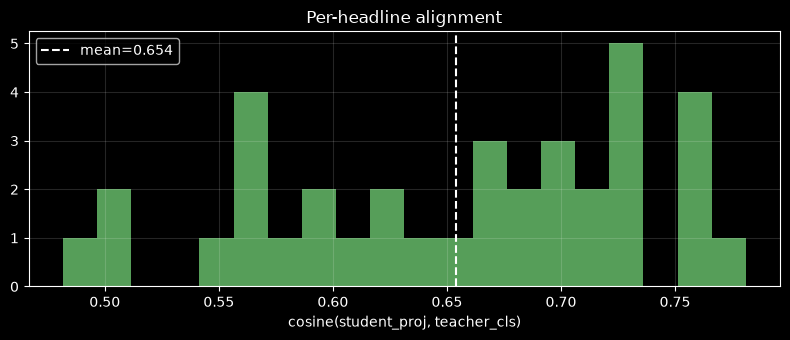

In [6]:
student.eval()
with torch.no_grad():
    s_emb, s_proj = student(ids, mask)
s_emb = s_emb.cpu().numpy()
s_proj = s_proj.cpu().numpy()
t_cls = teacher_cls.cpu().numpy()

cos_align = F.cosine_similarity(torch.tensor(s_proj), torch.tensor(t_cls)).numpy()


def linear_cka(X, Y):
    X = X - X.mean(0)
    Y = Y - Y.mean(0)
    hsic = np.linalg.norm(Y.T @ X, "fro") ** 2
    return hsic / (np.linalg.norm(X.T @ X, "fro") * np.linalg.norm(Y.T @ Y, "fro"))


def knn_overlap(A, B, k=5):
    def neigh(M):
        M = M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
        sim = M @ M.T
        np.fill_diagonal(sim, -np.inf)
        return np.argsort(-sim, axis=1)[:, :k]

    na, nb = neigh(A), neigh(B)
    return np.mean([len(set(a) & set(b)) / k for a, b in zip(na, nb)])


cka = linear_cka(t_cls, s_emb)
overlap = knn_overlap(t_cls, s_emb, k=5)
print(f"Mean cosine alignment (student_proj vs teacher_cls): {cos_align.mean():.3f}")
print(f"Linear CKA (teacher_cls vs student_emb)            : {cka:.3f}")
print(f"kNN(k=5) retrieval overlap                         : {overlap:.2%}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(cos_align, bins=20, color=COLORS["success"], alpha=0.85)
ax.axvline(cos_align.mean(), color="white", ls="--", label=f"mean={cos_align.mean():.3f}")
ax.set_xlabel("cosine(student_proj, teacher_cls)")
ax.set_title("Per-headline alignment")
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 5. Downstream probe — sentiment classification

A linear classifier on *frozen* embeddings tells us whether the semantics needed
for the task survived. We 5-fold cross-validate teacher (768-d CLS) vs student
(64-d embedding) vs a random-chance reference (⅓).

In [7]:
def probe_acc(Xemb):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=1.0))
    return cross_val_score(
        clf, Xemb, LABELS, cv=StratifiedKFold(5, shuffle=True, random_state=0)
    ).mean()


acc_t, acc_s = probe_acc(t_cls), probe_acc(s_emb)
print(f"Teacher CLS  (768-d) sentiment probe acc: {acc_t:.2%}")
print(f"Student emb  (64-d)  sentiment probe acc: {acc_s:.2%}")
print(f"Random chance                           : {1 / 3:.2%}")
print(
    f"Retained: {acc_s / acc_t:.0%} of the teacher's linear-probe accuracy at "
    f"{t_cls.shape[1] // s_emb.shape[1]}× smaller embedding"
)

Teacher CLS  (768-d) sentiment probe acc: 91.79%
Student emb  (64-d)  sentiment probe acc: 94.64%
Random chance                           : 33.33%
Retained: 103% of the teacher's linear-probe accuracy at 12× smaller embedding


## 6. Embedding spaces — t-SNE

Side by side, teacher vs student, coloured by the true label. If distillation
worked, the student's 64-d space should show the same broad sentiment structure
as the teacher's 768-d space.

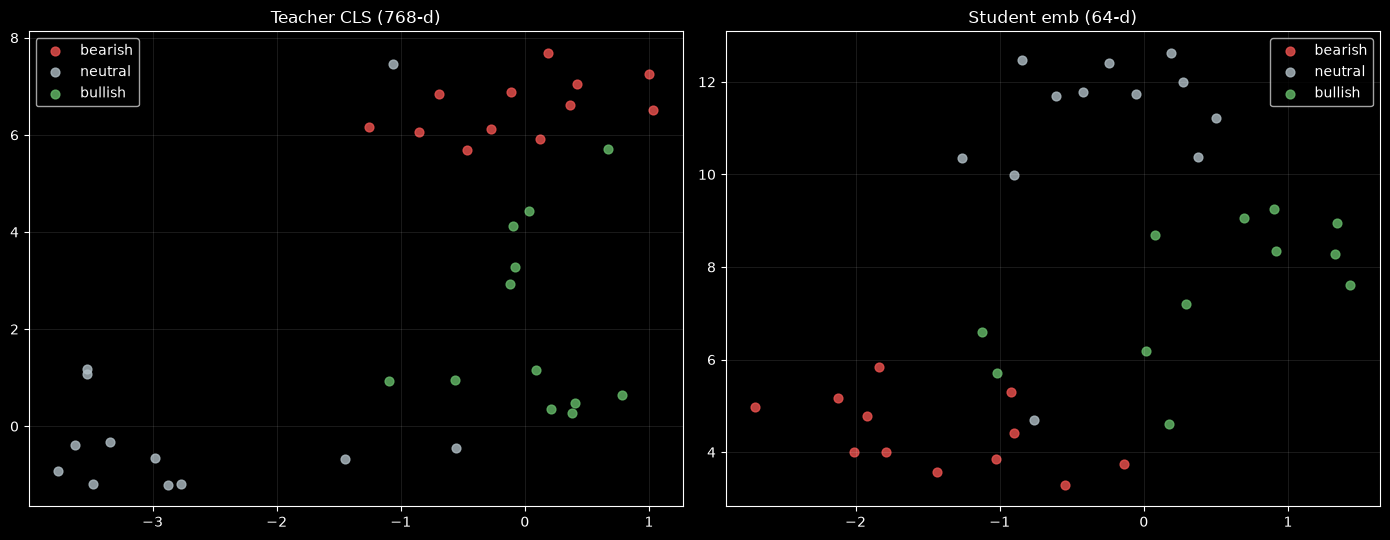

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
palette = {
    0: COLORS["danger"],
    1: COLORS["neutral"] if "neutral" in COLORS else "#B0BEC5",
    2: COLORS["success"],
}
pp = min(15, len(HEADLINES) - 1)
for ax, emb, title in [
    (axes[0], t_cls, "Teacher CLS (768-d)"),
    (axes[1], s_emb, "Student emb (64-d)"),
]:
    xy = TSNE(n_components=2, perplexity=pp, random_state=42).fit_transform(emb)
    for lab in (0, 1, 2):
        m = LABELS == lab
        ax.scatter(xy[m, 0], xy[m, 1], c=palette[lab], label=LABEL_NAMES[lab], s=40, alpha=0.8)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.1)
plt.tight_layout()
plt.show()

## 7. Inference speed — the whole point of distillation

We time both encoders on a 32-headline batch (warm-up + repeats), on whatever
devices are available, and report latency, throughput and the speed-up.

        teacher_ms  student_ms  speedup  teacher_hl/s  student_hl/s
device                                                             
cpu        1799.10     2808.67     0.64         17.79         11.39
cuda         93.29        4.14    22.51        343.03       7722.37


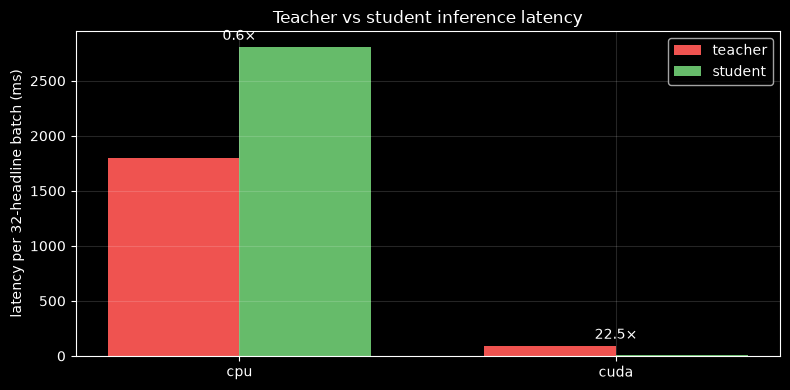

In [9]:
@torch.no_grad()
def bench(model_fn, enc, dev, iters=20, warmup=3):
    for _ in range(warmup):
        model_fn(enc)
    if dev == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(iters):
        model_fn(enc)
    if dev == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / iters


batch = HEADLINES[:32] * 1
rows = []
for dev in ["cpu", "cuda"] if torch.cuda.is_available() else ["cpu"]:
    teacher.to(dev)
    student.to(dev)
    enc = tokenizer(
        batch, padding="max_length", truncation=True, max_length=64, return_tensors="pt"
    ).to(dev)
    t_lat = bench(lambda e: teacher(**e).last_hidden_state[:, 0], enc, dev)
    s_lat = bench(lambda e: student(e["input_ids"], e["attention_mask"]), enc, dev)
    rows.append(
        {
            "device": dev,
            "teacher_ms": t_lat * 1e3,
            "student_ms": s_lat * 1e3,
            "speedup": t_lat / s_lat,
            "teacher_hl/s": len(batch) / t_lat,
            "student_hl/s": len(batch) / s_lat,
        }
    )
teacher.to(device)
student.to(device)
import pandas as pd

bench_df = pd.DataFrame(rows).set_index("device")
print(bench_df.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(bench_df))
w = 0.35
ax.bar(x - w / 2, bench_df["teacher_ms"], w, color=COLORS["danger"], label="teacher")
ax.bar(x + w / 2, bench_df["student_ms"], w, color=COLORS["success"], label="student")
for i, (_, r) in enumerate(bench_df.iterrows()):
    ax.annotate(
        f"{r['speedup']:.1f}×",
        (i, max(r["teacher_ms"], r["student_ms"])),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        color="white",
    )
ax.set_xticks(x)
ax.set_xticklabels(bench_df.index)
ax.set_ylabel("latency per 32-headline batch (ms)")
ax.set_title("Teacher vs student inference latency")
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 8. Token attribution — Integrated Gradients

Which tokens drive the student's embedding? Integrated Gradients (Sundararajan
et al., 2017) integrates the gradient of the embedding norm along a straight path
from a zero baseline to the real token embeddings.

> **Note.** The backend helper `DistilledFinancialEncoder.integrated_gradients`
> currently breaks here: Captum expands the input to `n_steps` rows in a single
> forward, but the closed-over `attention_mask` stays batch-1, so the
> transformer's `src_key_padding_mask` size mismatches (`RuntimeError: Mask size
> should match input size`). We compute the same attribution notebook-locally
> with a per-step (batch-1) loop — worth fixing in the helper separately.

• Earnings smash expectations and guidance is raised sharply.
    top tokens: raised(-0.08), and(+0.08), guidance(-0.07), earnings(-0.06), is(+0.04), expectations(-0.04)

• Shares plunge after the company slashes full-year guidance.
    top tokens: ##es(+0.19), full(+0.12), -(-0.08), after(+0.08), company(-0.08), slash(+0.06)



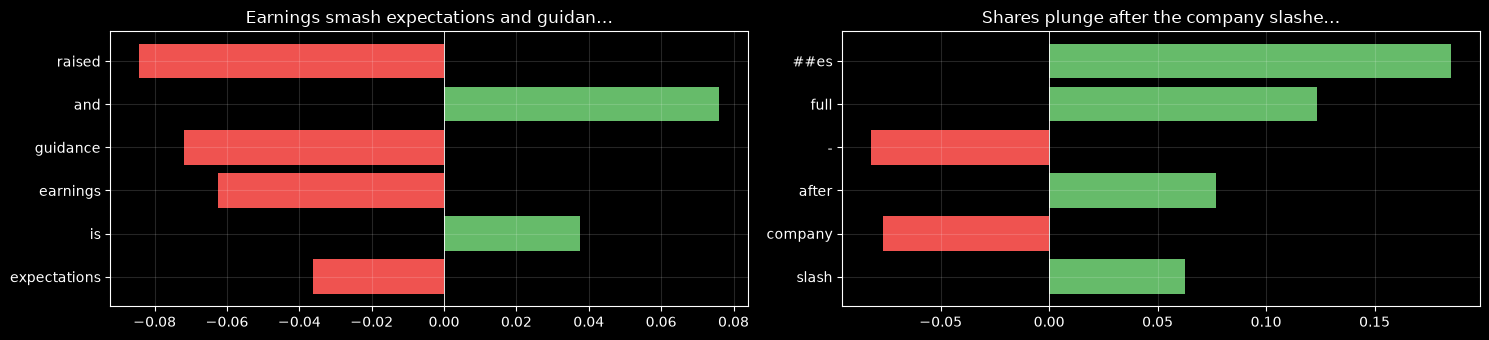

In [10]:
def token_saliency(text: str, steps: int = 48, top_k: int = 6):
    student.eval()
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to(device)
    ids = enc["input_ids"]
    base = student.token_emb(ids).detach()  # (1, T, H)
    grads = torch.zeros_like(base)
    for a in torch.linspace(0.0, 1.0, steps, device=device):
        e = (a * base).detach().requires_grad_(True)
        t = e.shape[1]
        pos = torch.arange(t, device=device).unsqueeze(0)
        h = student.layer_norm(e + student.pos_emb(pos))
        h = student.transformer(h)  # single sentence → no padding mask
        out = student.to_embedding(h.mean(1)).norm()
        (g,) = torch.autograd.grad(out, e)
        grads += g
    ig = (base * grads / steps).sum(-1).squeeze(0)  # (T,)
    toks = tokenizer.convert_ids_to_tokens(ids.squeeze(0).tolist())
    pairs = [(tk, float(s)) for tk, s in zip(toks, ig.tolist()) if tk not in ("[CLS]", "[SEP]")]
    return sorted(pairs, key=lambda p: abs(p[1]), reverse=True)[:top_k]


examples = [
    "Earnings smash expectations and guidance is raised sharply.",
    "Shares plunge after the company slashes full-year guidance.",
]
fig, axes = plt.subplots(1, 2, figsize=(15, 3.5))
for ax, text in zip(axes, examples):
    toks = token_saliency(text)
    print(f"• {text}\n    top tokens: " + ", ".join(f"{t}({s:+.2f})" for t, s in toks) + "\n")
    names = [t for t, _ in toks][::-1]
    vals = [s for _, s in toks][::-1]
    ax.barh(names, vals, color=[COLORS["success"] if v > 0 else COLORS["danger"] for v in vals])
    ax.axvline(0, color="white", lw=0.6)
    ax.set_title(text[:38] + "…")
    ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## What this test proves

A passing smoke test means the **gradient pathway is correct** (teacher → student
→ loss → backprop reaches all student params), the student is **built to spec**
(~11M params, returns `(embedding, teacher_projection)`), and — new here — that
the student **inherits the teacher's geometry** (cosine alignment, CKA, kNN
overlap, and a competitive linear sentiment probe) at a **measured multi-fold
speed-up and size reduction**. A real run repeats this over millions of headlines
with warm-up + cosine schedule and held-out validation
(`backend/perception/semantic/distillation.py`). *Failing this smoke test means
the production script will also fail — fix it here first.*